<a href="https://colab.research.google.com/github/Axel3D2Y/Proyect-End-to-End-Ecommerce/blob/main/04_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transferencia de aprendizaje

Debido a las limitaciones que tenemos con respecto al uso de una gpu procedemos a realizar esta parte en Google colab ya que nos proporciona un entorno en el cual podemos desarrollar nuestro modelo usando un modelo para entrenado.

1. El principal motivo por el cual usaremos un modelo pre entrenado es la limitación de la cantidad de datos tenemos una cantidad muy insignificante de datos para que nuestro modelo pueda aprender las relaciones semánticas correspondientes para este caso utilizaremos un modelo para entrenado de huggin face
2. Otro motivo del por cuál preferimos usar un modelo pre entrenado es que no tenemos la infraestructura suficiente para poder realizar todo el modelo Transformer para que aprendan todos los parámetros correspondientes del modelo se requiere una infraestructura muy grande y un gran tiempo de computación desafortunadamente no contamos con estas herramientas por lo tanto decidimos usar esta herramienta

3. Finalmente nos proporciona una api fácil de usar intuitiva que se conecta de manera optimizada para pytorch que es el entorno en el cual desarrollaremos nuestro proyecto.

La arquitectura que usaremos para entrenar nuestro modelo es una red entrenada llamada Bert base portugués case disponible en el siguiente enlace de huggin face optimizada para el lenguaje portugués.
Desafortunadamente para tensorflow no está disponible este modelo es esta la razón por la cual decidimos usar pytorch en su lugar.


In [ ]:
ruta_datos_oro = DataSave(ruta="data/gold")

tablas = ruta_datos_oro.cargar_todo()

📂 dim_order_payments.parquet cargado | Filas: 103,886
📂 dim_customers.parquet cargado | Filas: 99,441
📂 dim_orders.parquet cargado | Filas: 99,441
📂 dim_geolocation.parquet cargado | Filas: 1,000,163
📂 dim_orders_reviews.parquet cargado | Filas: 99,224
📂 dim_time.parquet cargado | Filas: 98,875
📂 dim_products.parquet cargado | Filas: 32,951
📂 fact_sales.parquet cargado | Filas: 117,604
📂 dim_order_items.parquet cargado | Filas: 112,650
📂 dim_sellers.parquet cargado | Filas: 3,095
Se cargaron 10 archivos exitosamente


In [ ]:
import matplotlib.pyplot as plt
import duckdb
import pandas as pd
import matplotlib
from scipy import stats


In [ ]:
def resumen_tabla(dataframes: dict) -> pd.DataFrame:
  filas = []
  for name, df in dataframes.items():
    null_cols = df.columns[df.isnull().any()].tolist()
    filas.append({
        "dataset":         name,
        "n_filas":         df.shape[0],
        "n_columnas":      df.shape[1],
        "val_nulos":     df.isnull().sum().sum(),
        "qty_null_columns": len(null_cols),
        "null_columns":    ", ".join(null_cols) if null_cols else ""
    })
  return pd.DataFrame(filas)

def styling_pandas(df: dict) -> pd.DataFrame:
  # Get the names of the numeric columns
  num_cols_names = df.select_dtypes(include='number').columns.tolist()
  styled = (
      df.style
      .background_gradient(
          cmap="Blues",
          subset=num_cols_names # Pass the list of column names here
      )
      .set_properties(**{
          "font-size": "12px",
          "border": "1px solid #ddd",
          "text-align": "center"
      })
      .set_table_styles([{
          "selector": "th",
          "props": [
              ("background-color", "#2c3e50"),
              ("color", "white"),
              ("font-size", "13px"),
              ("text-align", "center"),
              ("padding", "8px")
          ]
      }])
      .format({
          "n_filas":          "{:,}", # Corrected column name
          "val_nulos":     "{:,}", # Corrected column name
          "qty_null_columns": "{:,}"
      })
  )
  return styled

In [ ]:
resumen = resumen_tabla(tablas)
styling_pandas(resumen)

,dataset,n_filas,n_columnas,val_nulos,qty_null_columns,null_columns
0,dim_order_payments,"103,886",5,0,0,
1,dim_customers,"99,441",4,0,0,
2,dim_orders,"99,441",8,"4,908",3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,dim_geolocation,"1,000,163",5,0,0,
4,dim_orders_reviews,"99,224",4,"58,247",1,review_comment_message
5,dim_time,"98,875",6,0,0,
6,dim_products,"32,951",4,614,3,"product_category_name, product_weight_g, product_length_cm"
7,fact_sales,"117,604",8,3,1,payment_value
8,dim_order_items,"112,650",7,0,0,
9,dim_sellers,"3,095",4,0,0,


In [ ]:
def resumen_columnas(tabla: dict) -> pd.DataFrame:
    filas = []
    for name, df in tablas.items():
      for col in df.columns:
          val_null = df[col].isnull().sum()
          dtype = str(df[col].dtype)

          filas.append({
              "nombre_df":  name,
              "nombre_col":  col,
              "val_null":  val_null,
              "tipo":  dtype,
          })

    return pd.DataFrame(filas)


In [ ]:
resumen_columnas(tablas)

,nombre_df,nombre_col,val_null,tipo
0,dim_order_payments,order_id,0,object
1,dim_order_payments,payment_sequential,0,int64
2,dim_order_payments,payment_type,0,object
3,dim_order_payments,payment_installments,0,int64
4,dim_order_payments,payment_value,0,float64
5,dim_customers,customer_id,0,object
6,dim_customers,customer_zip_code_prefix,0,float64
7,dim_customers,customer_city,0,object
8,dim_customers,customer_state,0,object
9,dim_orders,order_id,0,object


# NLP SENTIMENT ANALYST

Debido a la cantidad y calidad de las reviews hemos decidido usar un modelo preentrenado para el analisis de sentimiento.


- Segmentación RFM: Implementar un algoritmo de K-Means Clustering para agrupar clientes según Recency, Frequency, Monetary. No uses reglas arbitrarias; deja que el modelo encuentre los centroides óptimos
- Análisis de Sentimiento: dicen las reseñas de 1 a 3 estrellas sobre la calidad del producto frente a la logística?

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.optim import AdamW
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [ ]:
# hacemos la conexion con db guardo en con
con = duckdb.connect()
# registramos cada tabla
for nombre, df in tablas.items():
    con.register(nombre, df)
# usamos la conexion especifica y no la global duckdb
def query(sql: str, conexion=con) -> pd.DataFrame:
    try:
        resultado = conexion.query(sql).df()
        return resultado
    except Exception as e:
        print(f"Error en la query: {e}")
        return pd.DataFrame()

In [ ]:
query_1 ="""
SELECT
  order_id,
  review_score,
  review_comment_message
FROM
  dim_orders_reviews
"""
df_reviews = query(query_1, conexion=con)

In [ ]:
class OlistDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
class TransferLearning:
  MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
  labels = {0: "negativo", 1: "neutro", 2: "positivo"}


  def __init__(self, max_length: int = 128, batch_size: int = 32, num_labels: int = 3):
    self.max_length = max_length
    self.batch_size = batch_size
    self.num_labels = num_labels
    self.tokenizer = None
    self.model = None
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # opcion para usar el los nucleos cuda de la gpu si es que los tiene
    self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} # diccionario para las perdidas, a diferencia de tensorflos no se agregan de forma automatica

# ====================================================================
# Cambiamos calificaciones de reviews a etiquetas.
# ====================================================================
  def preparar_datos(self, df: pd.DataFrame, column: str = 'review_score') -> pd.DataFrame:
    def review_a_etiquetas(score: int) -> int:
        if score <= 2:   return 0
        elif score == 3: return 1
        else:            return 2

    df = df.copy()
    df['Etiquetas'] = df[column].apply(review_a_etiquetas)
    print("Distribución de etiquetas :")
    for label, clase in self.labels.items():
      total = (df['Etiquetas'] == label).sum()
      porcentaje  = (total/len(df))*100
      print(f'{clase}: {total:,} - ({porcentaje:.1f}%)')
    print("Creacion de la clase etiquetas completada. ")
    print("="*50)
    return df

# ====================================================================
# Cambiamos calificaciones de reviews a etiquetas.
# ====================================================================
  def split_data(self, df: pd.DataFrame, review_comment_message: str = "review_comment_message", test_size: float = 0.2):
    X = df[review_comment_message].fillna('').tolist()
    y = df['Etiquetas'].tolist()
    X_train, X_test, y_train, y_test = train_test_split(
        X,y,
        test_size= test_size,
        stratify= y,
        random_state=42
        )
    print('Split de datos proporcional realizada...')
    print("="*50)
    return  X_train, X_test, y_train, y_test


# ====================================================================
# Cargamos del modelo BERTimbau para hacer Transfer Learning.
# ====================================================================
  def cargar_modelo(self):
    self.tokenizer = AutoTokenizer.from_pretrained(self.MODEL_NAME) # Cargamos el modelo usando optimo para usar pytorch
  # self.model = TFAutoModelForSequenceClassification.from_pretrained(self.MODEL_NAME, num_labels=self.num_labels)  -> Se  usa cuando se  carga el modelo usando tensorflow
    self.model = AutoModelForSequenceClassification.from_pretrained(self.MODEL_NAME, num_labels=self.num_labels)
    self.model.to(self.device)  # Cargamos el modelo usando
    print(f'✅ Modelo {self.MODEL_NAME} cargado en {self.device}')
    print("="*50)

# ====================================================================
# Cargamos del modelo BERTimbau para hacer Transfer Learning.
# ====================================================================
  def _tokenizar(self, comentarios: str) -> dict:
    return self.tokenizer(
              comentarios, padding=True, truncation=True,
              max_length=self.max_length, return_tensors="pt"
          )

# ====================================================================
# Creamos con tf.data.Dataset los dataset optimizados para entrenamiento.
# ====================================================================
  def crear_dataloaders(self, X_train, X_test, y_train, y_test):
    train_encodings = self._tokenizar(X_train)
    test_encodings = self._tokenizar(X_test)
    train_dataset = OlistDataset(train_encodings, y_train)
    test_dataset = OlistDataset(test_encodings, y_test)
    self.train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
    self.test_loader = DataLoader(test_dataset, batch_size=self.batch_size)
    print("DataLoaders de PyTorch listos.")
    print(f"Train: {len(self.train_loader ):,} | Test: {len(self.test_loader):,}")
    print("="*50)


# ====================================================================
# Transfer learning usando BERT descogelando el entrenamiento de las ultimas capas
# ====================================================================
  def transfer_learning(self, layers_unfreeze = 2):
      for param in self.model.bert.parameters():
            param.requires_grad = False # Congelamos todas las capas del modelo

      for layer in self.model.bert.encoder.layer[-layers_unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True # Descongelamos la  ultima capa del modelo

      for param in self.model.classifier.parameters():
          param.requires_grad = True # la capa de clasificacion tambien debe de estar descongelado.

      trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
      non_trainable_params = sum(p.numel() for p in self.model.parameters() if not p.requires_grad)
      print(f"Parámetros entrenables: {trainable_params:,}")
      print(f"Parámetros no entrenables: {non_trainable_params:,}")
      print("="*50)


# ====================================================================
# Entrenamiento:
# ====================================================================
  def train(self, epochs=2, learning_rate = 3e-5):
    optimizer = AdamW(self.model.parameters(), lr = learning_rate) # Variente de Adam con una tasa de decay
    num_training_steps = epochs * len(self.train_loader) # pasos de entremiento en total
    learning_rate_schedule = get_scheduler("linear",  optimizer =optimizer,num_warmup_steps=0,num_training_steps=num_training_steps)

    for epoch in range(epochs):
      self.model.train()  # le decimos que vamos a entrenar el modelo
      total_loss, correct, total = 0, 0, 0


      for batch in tqdm(self.train_loader, desc= f"Epoca {epoch + 1}/{epochs}"):
# pasamos el batch del cpu a la gpu
        batch = {k: v.to(self.device) for k, v in batch.items()}

# Forward pass
        outputs = self.model(**batch) # pasa el lote
        loss = outputs.loss # calculala perdida
        loss.backward() # hace el Backpropagation para actualizar la perdida con respeecto al gradiente
        optimizer.step() # actualiza los pesos obtenidos en el Backpropagation
        learning_rate_schedule.step() # actualiza el lr gradualmente
        optimizer.zero_grad() # limpia gradientes para otro batch

        total_loss += loss.item() # perdida acumulada
        logits = outputs.logits # calcula la salida sin procesar
        predictions = torch.argmax(logits, dim=-1) # prob a clases
        correct += (predictions == batch['labels']).sum().item() # etiquetas correctas
        total += batch['labels'].size(0)

      self.history['train_loss'].append(total_loss/len(self.train_loader))
      self.history['train_acc'].append(correct / total)
      print(f'Loss: {self.history['train_loss'][-1]:.4f} --- Accuracy:{self.history['train_acc'][-1]:.4%} ')
      print("="*50)


# ====================================================================
# PREDICCIONES
# ====================================================================

  def predict(self, review ):
    self.model.eval()
    if isinstance(review,str):
      review = [review]
    inputs = self._tokenizar(review).to(self.device)


    with torch.no_grad():
      outputs = self.model(**inputs)
      probs = torch.nn.functional.softmax(outputs.logits, dim=-1) #  equivalente en tensorflow proba = tf.nn.softmax(outputs.logits, axis=-1).numpy()

    probs = probs.cpu().numpy()
    return pd.DataFrame([{
        "review": t[:50] + "..." if len(t) > 50 else t,
        "sentimiento": self.labels[int(np.argmax(p))],
        "confianza": round(float(np.max(p)), 4),
        "p_negativo": round(float(p[0]), 4),
        "p_neutro": round(float(p[1]), 4),
        "p_positivo": round(float(p[2]), 4),
    } for t,p in zip(review, probs)])


# ====================================================================
# Guardar modelo
# ====================================================================
  def guardar(self, path: str = "models/sentiment_olist"):
      self.model.save_pretrained(path)
      self.tokenizer.save_pretrained(path)
      print(f"Modelo guardado en: {path}")

# ====================================================================
# Cargar modelo guardado
# ====================================================================
  def cargar(self, path: str = "models/sentiment_olist"):
      self.tokenizer = AutoTokenizer.from_pretrained(path)
      self.model = AutoModelForSequenceClassification.from_pretrained(path)
      print(f"Modelo cargado desde: {path}")


# ====================================================================
# Cargar modelo guardado
# ====================================================================
  def plot_training(self):
      fig, axes = plt.subplots(1, 2, figsize=(14, 5))
      axes[0].plot(self.history['train_acc'], label="Train Acc")
      axes[0].set_title("Accuracy")
      axes[1].plot(self.history['train_loss'], label="Train Loss")
      axes[1].set_title("Loss")
      plt.show()

In [ ]:
model = TransferLearning(
    max_length = 128,
    batch_size = 16,
    num_labels = 3
)
df = model.preparar_datos(df_reviews)
X_train, X_test, y_train, y_test = model.split_data(df)


Distribución de etiquetas :
negativo: 14,575 - (14.7%)
neutro: 8,179 - (8.2%)
positivo: 76,470 - (77.1%)
Creacion de la clase etiquetas completada. 
Split de datos proporcional realizada...


Por problemas de compatibilidad con la barra de progreso de tqdm vamos a solo colocar las imagenes de las salidas

In [ ]:
model.cargar_modelo()


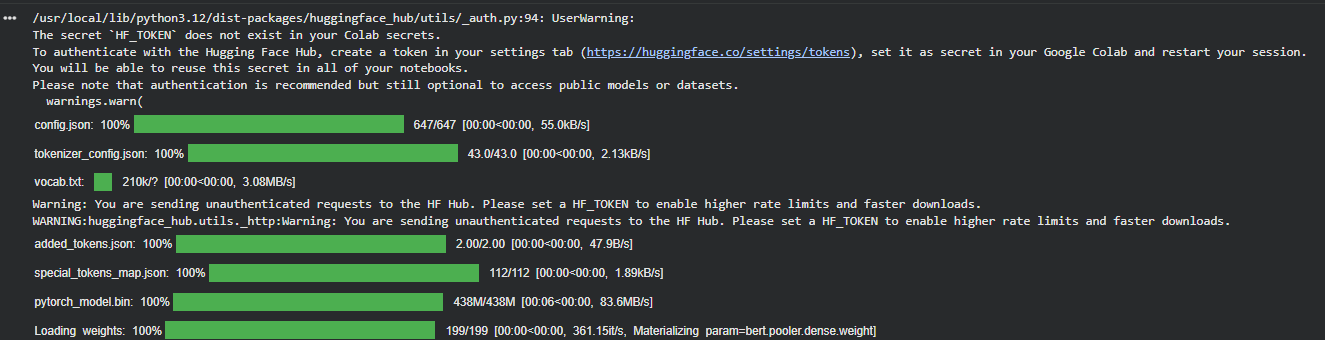

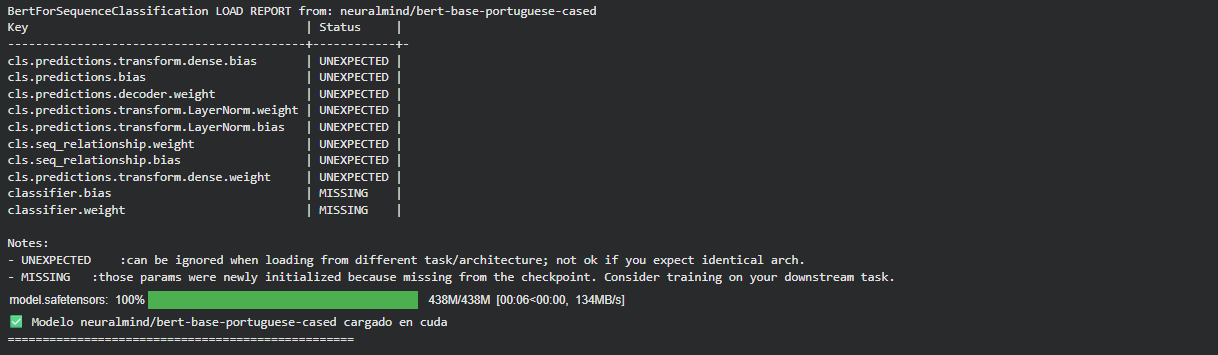

In [ ]:
model.crear_dataloaders(X_train, X_test, y_train, y_test)
model.transfer_learning(layers_unfreeze=2)


DataLoaders de PyTorch listos.
Train: 4,962 | Test: 1,241
Parámetros entrenables: 14,178,051
Parámetros no entrenables: 94,747,392


In [ ]:
model.train(epochs = 3, learning_rate=3e-5)


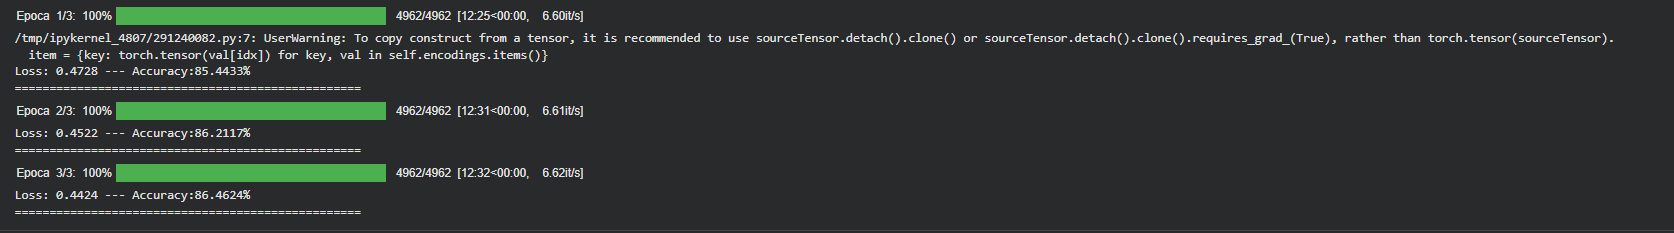

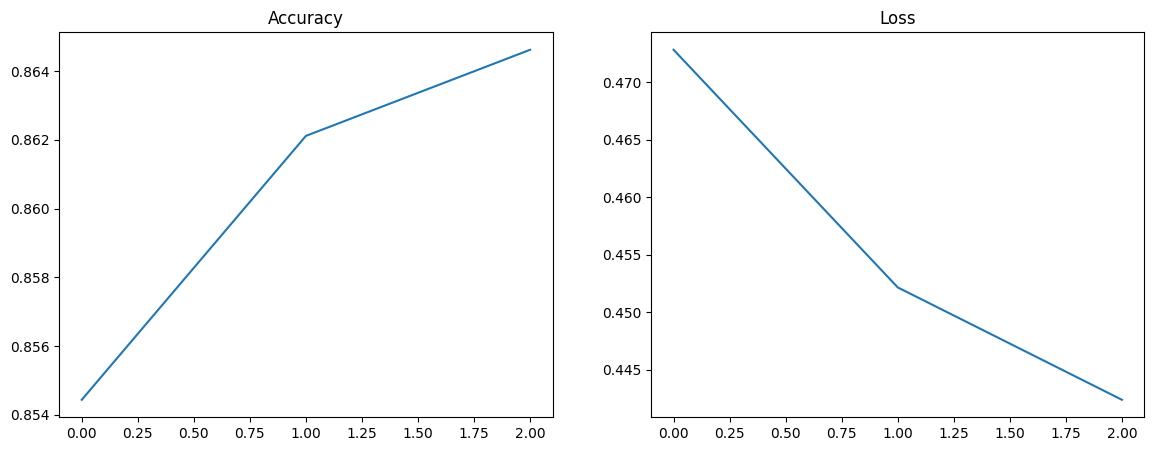

In [ ]:
model.plot_training()

In [ ]:
predicciones = model.predict(X_test[:10])
print(predicciones)

                                              review sentimiento  confianza  \
0                                                       positivo     0.8637   
1  Produto atendeu minhas necessidades e a entreg...    positivo     0.9762   
2                              Adorei perfeito lindo    positivo     0.9898   
3                                                       positivo     0.8637   
4                                                       positivo     0.8637   
5                                                       positivo     0.8637   
6  gostei do formato e da qualidade, espero que d...    positivo     0.9772   
7  Comprei a base dermacol cor 207, pela cor most...    negativo     0.8505   
8  Recebi o produto inteiro. \r\nApesar de um pou...    positivo     0.9367   
9                                                       positivo     0.8637   

   p_negativo  p_neutro  p_positivo  
0      0.0592    0.0771      0.8637  
1      0.0033    0.0205      0.9762  
2      0.0037   

In [ ]:
resultado = model.predict("Produto péssimo, horrível!")
print(resultado)

                       review sentimiento  confianza  p_negativo  p_neutro  \
0  Produto péssimo, horrível!    negativo     0.9698      0.9698    0.0221   

   p_positivo  
0      0.0081  
